# 01 — Genre Classification
**Spotify Data Mining | CISC 4631 | Group 3**

**Research Question:** Can audio features predict song genre?

**Approach:** Logistic Regression (linear baseline) vs. Random Forest (non-linear). Compare accuracy,
F1 scores, and feature importance.

> **Prerequisite:** Run `00_data_setup.ipynb` first to generate `data/df_genre_balanced.csv`.

## 0. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

# Shared constants (keep in sync with 00_data_setup.ipynb)
SEED            = 42
DRIVE_DATA_PATH = '/content/drive/MyDrive/data-mining-spotify-team3/cleanedData'
ALL_FEATURES = [
    'danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'key', 'mode'
]
np.random.seed(SEED)

## 1. Load Data

In [ ]:
import os
df = pd.read_csv(os.path.join(DRIVE_DATA_PATH, 'df_genre_balanced.csv'))
print(f'Loaded: {df.shape}')
print('\nGenre counts:')
print(df['genre'].value_counts())
df.head()

Loaded: (48265, 14)

Genre counts:
genre
Classical       6895
Country/Folk    6895
Electronic      6895
Hip-Hop/R&B     6895
Jazz/Blues      6895
Pop             6895
Rock            6895
Name: count, dtype: int64


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,key,mode,genre,year
0,0.139,0.0948,-19.576,0.0382,0.9400,0.953000,0.333,0.0899,142.335,271907,10,1,Classical,2008
1,0.485,0.2280,-11.844,0.0481,0.8810,0.000000,0.170,0.4020,114.426,137360,2,1,Classical,2002
2,0.439,0.3920,-8.085,0.0305,0.5700,0.000003,0.334,0.3890,94.393,171280,6,1,Classical,2018
3,0.693,0.5350,-10.377,0.1120,0.3470,0.223000,0.121,0.4970,159.978,335227,9,1,Classical,2003
4,0.357,0.6990,-5.173,0.0501,0.0508,0.000003,0.403,0.2290,147.477,251080,7,1,Classical,2018


## 2. Train / Test Split
Three-way split (60/20/20) per instructor feedback. Train is used for fitting + 10-fold CV. Eval is held out for model comparison and tuning decisions. Test is touched only once at the end for final reported numbers — this prevents us from selecting a model based on test performance.

# split to 3 parts (train, eval., test)
# feature selection

In [ ]:
X = df[ALL_FEATURES]
y = df['genre']

# First split: 80% train+eval, 20% test (held out, touched once)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# Second split: 75/25 of the 80% = 60% train, 20% eval
X_train, X_eval, y_train, y_eval = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=SEED, stratify=y_trainval
)

print(f'Train: {X_train.shape[0]:,} ({X_train.shape[0] / len(X):.0%})')
print(f'Eval:  {X_eval.shape[0]:,} ({X_eval.shape[0] / len(X):.0%})')
print(f'Test:  {X_test.shape[0]:,} ({X_test.shape[0] / len(X):.0%})')

print('\nClass distribution (train):')
print(y_train.value_counts())
print('\nClass distribution (eval):')
print(y_eval.value_counts())
print('\nClass distribution (test):')
print(y_test.value_counts())

Train: 28,959 (60%)
Eval:  9,653 (20%)
Test:  9,653 (20%)

Class distribution (train):
genre
Pop             4137
Electronic      4137
Country/Folk    4137
Rock            4137
Hip-Hop/R&B     4137
Classical       4137
Jazz/Blues      4137
Name: count, dtype: int64

Class distribution (eval):
genre
Pop             1379
Electronic      1379
Classical       1379
Rock            1379
Jazz/Blues      1379
Hip-Hop/R&B     1379
Country/Folk    1379
Name: count, dtype: int64

Class distribution (test):
genre
Hip-Hop/R&B     1379
Pop             1379
Country/Folk    1379
Electronic      1379
Rock            1379
Classical       1379
Jazz/Blues      1379
Name: count, dtype: int64


## 3. Feature Selection
Rank the 12 audio features by mutual information with the genre label. Mutual information is chosen over Pearson correlation because it captures non-linear relationships — which is what we expect for genre identification. Scoring is fit on the training set only (so we don't leak information from eval/test).

Mutual information ranking:
         Feature  MI Score
    acousticness  0.244220
          energy  0.190538
           tempo  0.131695
    danceability  0.130675
     speechiness  0.104888
instrumentalness  0.100130
        loudness  0.099257
         valence  0.043423
     duration_ms  0.033484
            mode  0.019306
             key  0.019150
        liveness  0.017556


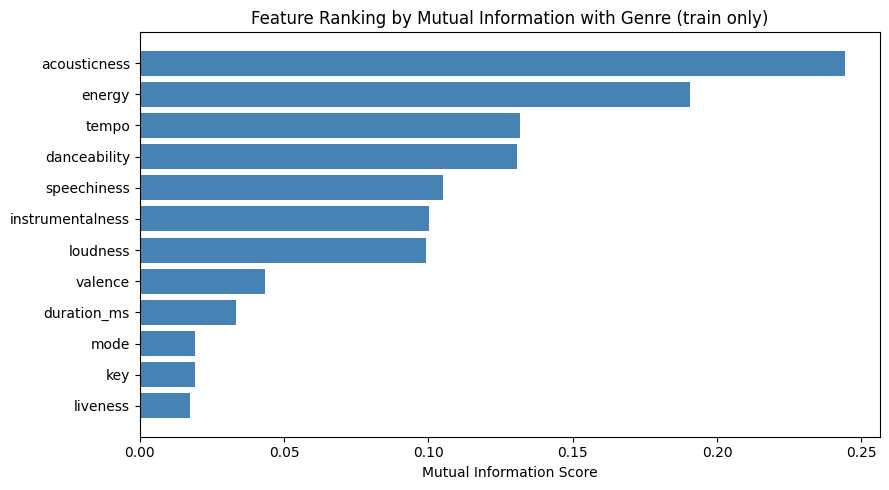


Selected top-12 features:
['acousticness', 'energy', 'tempo', 'danceability', 'speechiness', 'instrumentalness', 'loudness', 'valence', 'duration_ms', 'mode', 'key', 'liveness']

Dropped: []


In [ ]:
# Fit mutual-information scorer on train set only
mi_scorer = SelectKBest(score_func=mutual_info_classif, k='all')
mi_scorer.fit(X_train, y_train)

mi_scores = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'MI Score': mi_scorer.scores_
}).sort_values('MI Score', ascending=False).reset_index(drop=True)

print('Mutual information ranking:')
print(mi_scores.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(mi_scores['Feature'][::-1], mi_scores['MI Score'][::-1], color='steelblue')
ax.set_xlabel('Mutual Information Score')
ax.set_title('Feature Ranking by Mutual Information with Genre (train only)')
plt.tight_layout()
plt.show()

# Pick K: keep top-K features. Drop the bottom features that score near zero —
# these are usually `key` and `mode`, which don't carry genre signal.
# Tune K here based on the ranking above.
K = 12
SELECTED_FEATURES = mi_scores['Feature'].head(K).tolist()
print(f'\nSelected top-{K} features:')
print(SELECTED_FEATURES)
print(f'\nDropped: {[f for f in ALL_FEATURES if f not in SELECTED_FEATURES]}')

## 4. Models

### 4.1 Logistic Regression (Baseline)

In [ ]:
lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000, random_state=SEED))
])

# Fit on train (selected features only)
lr_model.fit(X_train[SELECTED_FEATURES], y_train)

# 10-fold CV on train — estimates stability without touching eval/test
cv_lr = cross_val_score(
    lr_model, X_train[SELECTED_FEATURES], y_train, cv=10, scoring='accuracy'
)
print("CV Accuracy (train, 10-fold): %0.2f (+/- %0.2f)" % (cv_lr.mean(), cv_lr.std() * 2))

# Evaluate on eval set
y_pred_lr_eval = lr_model.predict(X_eval[SELECTED_FEATURES])
print('\n--- EVAL SET ---')
print('Accuracy:', accuracy_score(y_eval, y_pred_lr_eval))
print(classification_report(y_eval, y_pred_lr_eval))

# Final test prediction (stored for Section 5 — do not tune against this)
y_pred_lr = lr_model.predict(X_test[SELECTED_FEATURES])

CV Accuracy (train, 10-fold): 0.43 (+/- 0.02)

--- EVAL SET ---
Accuracy: 0.43737698124935254
              precision    recall  f1-score   support

   Classical       0.44      0.49      0.46      1379
Country/Folk       0.28      0.24      0.26      1379
  Electronic       0.51      0.55      0.53      1379
 Hip-Hop/R&B       0.51      0.58      0.54      1379
  Jazz/Blues       0.40      0.39      0.40      1379
         Pop       0.25      0.15      0.19      1379
        Rock       0.53      0.67      0.59      1379

    accuracy                           0.44      9653
   macro avg       0.42      0.44      0.42      9653
weighted avg       0.42      0.44      0.42      9653



### 4.2 Random Forest

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=SEED,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print('Random Forest Accuracy:', accuracy_score(y_test, y_pred_rf))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf))

# Cross-validation
cv_rf = cross_val_score(rf_model, X, y, cv=10, scoring='accuracy')
print("CV Accuracy: %0.2f (+/- %0.2f)" % (cv_rf.mean(), cv_rf.std() * 2))

Random Forest Accuracy: 0.5033668289650886

Classification Report:
              precision    recall  f1-score   support

   Classical       0.53      0.53      0.53      1379
Country/Folk       0.38      0.35      0.36      1379
  Electronic       0.57      0.61      0.59      1379
 Hip-Hop/R&B       0.57      0.67      0.61      1379
  Jazz/Blues       0.45      0.52      0.48      1379
         Pop       0.35      0.23      0.28      1379
        Rock       0.59      0.62      0.61      1379

    accuracy                           0.50      9653
   macro avg       0.49      0.50      0.50      9653
weighted avg       0.49      0.50      0.50      9653

CV Accuracy: 0.51 (+/- 0.01)


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    random_state=SEED,
    n_jobs=-1
)

# Fit on train (selected features only)
rf_model.fit(X_train[SELECTED_FEATURES], y_train)

# 10-fold CV on train
cv_rf = cross_val_score(
    rf_model, X_train[SELECTED_FEATURES], y_train, cv=10, scoring='accuracy'
)
print("CV Accuracy (train, 10-fold): %0.2f (+/- %0.2f)" % (cv_rf.mean(), cv_rf.std() * 2))

# Evaluate on eval set
y_pred_rf_eval = rf_model.predict(X_eval[SELECTED_FEATURES])
print('\n--- EVAL SET ---')
print('Accuracy:', accuracy_score(y_eval, y_pred_rf_eval))
print(classification_report(y_eval, y_pred_rf_eval))

# Final test prediction (stored for Section 5)
y_pred_rf = rf_model.predict(X_test[SELECTED_FEATURES])


CV Accuracy (train, 10-fold): 0.51 (+/- 0.01)

--- EVAL SET ---
Accuracy: 0.5122759763803999
              precision    recall  f1-score   support

   Classical       0.53      0.56      0.55      1379
Country/Folk       0.38      0.36      0.37      1379
  Electronic       0.59      0.62      0.60      1379
 Hip-Hop/R&B       0.55      0.65      0.60      1379
  Jazz/Blues       0.47      0.54      0.50      1379
         Pop       0.33      0.20      0.25      1379
        Rock       0.64      0.65      0.65      1379

    accuracy                           0.51      9653
   macro avg       0.50      0.51      0.50      9653
weighted avg       0.50      0.51      0.50      9653



### 4.3 XGBoost

In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Encode labels for XGBoost
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_eval_enc  = le.transform(y_eval)
y_test_enc  = le.transform(y_test)

xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric='mlogloss',
    random_state=SEED,
    n_jobs=-1
)

# Fit on train
xgb_model.fit(X_train[SELECTED_FEATURES], y_train_enc)

# CV on train only
cv_xgb = cross_val_score(
    xgb_model,
    X_train[SELECTED_FEATURES],
    y_train_enc,
    cv=10,
    scoring='accuracy'
)
print("CV Accuracy (train, 10-fold): %0.2f (+/- %0.2f)" % (cv_xgb.mean(), cv_xgb.std() * 2))

# Evaluate on eval set
y_pred_xgb_eval_enc = xgb_model.predict(X_eval[SELECTED_FEATURES])
y_pred_xgb_eval = le.inverse_transform(y_pred_xgb_eval_enc)

print('\n--- EVAL SET ---')
print('Accuracy:', accuracy_score(y_eval, y_pred_xgb_eval))
print(classification_report(y_eval, y_pred_xgb_eval))

# Final test prediction (stored for final section)
y_pred_xgb_enc = xgb_model.predict(X_test[SELECTED_FEATURES])
y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)

CV Accuracy (train, 10-fold): 0.52 (+/- 0.01)

--- EVAL SET ---
Accuracy: 0.5215995027452606
              precision    recall  f1-score   support

   Classical       0.55      0.56      0.55      1379
Country/Folk       0.38      0.37      0.38      1379
  Electronic       0.62      0.64      0.63      1379
 Hip-Hop/R&B       0.59      0.65      0.62      1379
  Jazz/Blues       0.47      0.54      0.51      1379
         Pop       0.33      0.24      0.28      1379
        Rock       0.65      0.64      0.65      1379

    accuracy                           0.52      9653
   macro avg       0.51      0.52      0.52      9653
weighted avg       0.51      0.52      0.52      9653



In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_eval_enc = le.transform(y_eval)
y_test_enc = le.transform(y_test)

xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    n_estimators=1000,
    max_depth=10,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=1,
    gamma=0,
    reg_lambda=1,
    eval_metric='mlogloss',
    random_state=SEED,
    n_jobs=-1
)

xgb_model.fit(X_train[SELECTED_FEATURES], y_train_enc)

y_pred_xgb_eval = le.inverse_transform(xgb_model.predict(X_eval[SELECTED_FEATURES]))
print("Eval Accuracy:", accuracy_score(y_eval, y_pred_xgb_eval))
print(classification_report(y_eval, y_pred_xgb_eval))

y_pred_xgb = le.inverse_transform(xgb_model.predict(X_test[SELECTED_FEATURES]))

Eval Accuracy: 0.518077281674091
              precision    recall  f1-score   support

   Classical       0.54      0.56      0.55      1379
Country/Folk       0.38      0.37      0.37      1379
  Electronic       0.63      0.63      0.63      1379
 Hip-Hop/R&B       0.58      0.65      0.61      1379
  Jazz/Blues       0.47      0.54      0.50      1379
         Pop       0.31      0.24      0.27      1379
        Rock       0.65      0.64      0.65      1379

    accuracy                           0.52      9653
   macro avg       0.51      0.52      0.51      9653
weighted avg       0.51      0.52      0.51      9653



In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

for depth in [6, 8, 10]:
    for n in [300, 500, 800, 1000]:
        xgb_model = XGBClassifier(
            objective='multi:softmax',
            num_class=len(le.classes_),
            n_estimators=n,
            max_depth=depth,
            learning_rate=0.03,
            subsample=0.9,
            colsample_bytree=0.9,
            min_child_weight=1,
            gamma=0,
            reg_lambda=1,
            eval_metric='mlogloss',
            random_state=SEED,
            n_jobs=-1
        )

        xgb_model.fit(X_train[ALL_FEATURES], y_train_enc)
        y_pred_eval = le.inverse_transform(xgb_model.predict(X_eval[ALL_FEATURES]))
        acc = accuracy_score(y_eval, y_pred_eval)

        print(f"max_depth={depth}, n_estimators={n}, eval_acc={acc:.4f}")

max_depth=6, n_estimators=300, eval_acc=0.5126
max_depth=6, n_estimators=500, eval_acc=0.5178
max_depth=6, n_estimators=800, eval_acc=0.5195
max_depth=6, n_estimators=1000, eval_acc=0.5181
max_depth=8, n_estimators=300, eval_acc=0.5192
max_depth=8, n_estimators=500, eval_acc=0.5213
max_depth=8, n_estimators=800, eval_acc=0.5219
max_depth=8, n_estimators=1000, eval_acc=0.5209
max_depth=10, n_estimators=300, eval_acc=0.5191
max_depth=10, n_estimators=500, eval_acc=0.5221
max_depth=10, n_estimators=800, eval_acc=0.5204
max_depth=10, n_estimators=1000, eval_acc=0.5170


In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Use all 12 audio features
SELECTED_FEATURES = ALL_FEATURES.copy()

# Encode labels from the existing train/eval split
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_eval_enc = le.transform(y_eval)

# Best eval-tuned config
xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    n_estimators=500,
    max_depth=10,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=1,
    gamma=0,
    reg_lambda=1,
    eval_metric='mlogloss',
    random_state=SEED,
    n_jobs=-1
)

# Fit on TRAIN only
xgb_model.fit(X_train[SELECTED_FEATURES], y_train_enc)

# Predict on EVAL only
y_pred_xgb_eval_enc = xgb_model.predict(X_eval[SELECTED_FEATURES])
y_pred_xgb_eval = le.inverse_transform(y_pred_xgb_eval_enc)

print("Eval Accuracy:", accuracy_score(y_eval, y_pred_xgb_eval))
print("Eval Macro F1:", f1_score(y_eval, y_pred_xgb_eval, average='macro'))
print("Eval Weighted F1:", f1_score(y_eval, y_pred_xgb_eval, average='weighted'))
print(classification_report(y_eval, y_pred_xgb_eval))

Eval Accuracy: 0.5221174764321972
Eval Macro F1: 0.5163971023667728
Eval Weighted F1: 0.5163971023667729
              precision    recall  f1-score   support

   Classical       0.54      0.57      0.56      1379
Country/Folk       0.40      0.38      0.39      1379
  Electronic       0.63      0.62      0.63      1379
 Hip-Hop/R&B       0.58      0.66      0.62      1379
  Jazz/Blues       0.47      0.54      0.50      1379
         Pop       0.33      0.24      0.28      1379
        Rock       0.64      0.64      0.64      1379

    accuracy                           0.52      9653
   macro avg       0.51      0.52      0.52      9653
weighted avg       0.51      0.52      0.52      9653



In [ ]:
def add_audio_interactions(df):
    df = df.copy()
    df['energy_loudness'] = df['energy'] * df['loudness']
    df['dance_valence'] = df['danceability'] * df['valence']
    df['acoustic_instr'] = df['acousticness'] * df['instrumentalness']
    df['speech_dance'] = df['speechiness'] * df['danceability']
    return df

df2 = add_audio_interactions(df)

ALL_FEATURES_PLUS = ALL_FEATURES + [
    'energy_loudness',
    'dance_valence',
    'acoustic_instr',
    'speech_dance'
]

In [ ]:
# 1) Add audio-only interaction features
def add_audio_interactions(df):
    df = df.copy()
    df['energy_loudness'] = df['energy'] * df['loudness']
    df['dance_valence'] = df['danceability'] * df['valence']
    df['acoustic_instr'] = df['acousticness'] * df['instrumentalness']
    df['speech_dance'] = df['speechiness'] * df['danceability']
    return df

df_plus = add_audio_interactions(df)

# 2) Define expanded audio-only feature set
ALL_FEATURES_PLUS = ALL_FEATURES + [
    'energy_loudness',
    'dance_valence',
    'acoustic_instr',
    'speech_dance'
]

# 3) Rebuild X and y
X = df_plus[ALL_FEATURES_PLUS]
y = df_plus['genre']

# 4) Rebuild the same 60/20/20 split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

X_train, X_eval, y_train, y_eval = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=SEED, stratify=y_trainval
)

print(f"Train: {X_train.shape[0]:,}")
print(f"Eval:  {X_eval.shape[0]:,}")
print(f"Test:  {X_test.shape[0]:,}")

# 5) Encode labels for XGBoost
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_eval_enc = le.transform(y_eval)
y_test_enc = le.transform(y_test)

# 6) Tune XGBoost on the eval set
results = []

for depth in [6, 8, 10]:
    for n in [300, 500, 800, 1000]:
        xgb_model = XGBClassifier(
            objective='multi:softmax',
            num_class=len(le.classes_),
            n_estimators=n,
            max_depth=depth,
            learning_rate=0.03,
            subsample=0.9,
            colsample_bytree=0.9,
            min_child_weight=1,
            gamma=0,
            reg_lambda=1,
            eval_metric='mlogloss',
            random_state=SEED,
            n_jobs=-1
        )

        xgb_model.fit(X_train[ALL_FEATURES_PLUS], y_train_enc)

        y_pred_eval_enc = xgb_model.predict(X_eval[ALL_FEATURES_PLUS])
        y_pred_eval = le.inverse_transform(y_pred_eval_enc)

        acc = accuracy_score(y_eval, y_pred_eval)
        macro_f1 = f1_score(y_eval, y_pred_eval, average='macro')
        weighted_f1 = f1_score(y_eval, y_pred_eval, average='weighted')

        results.append({
            'max_depth': depth,
            'n_estimators': n,
            'eval_acc': acc,
            'eval_macro_f1': macro_f1,
            'eval_weighted_f1': weighted_f1
        })

        print(f"max_depth={depth}, n_estimators={n}, eval_acc={acc:.4f}")

results_df = pd.DataFrame(results).sort_values(
    by=['eval_acc', 'eval_macro_f1'],
    ascending=False
).reset_index(drop=True)

print("\nTop results:")
display(results_df.head(10))

Train: 28,959
Eval:  9,653
Test:  9,653
max_depth=6, n_estimators=300, eval_acc=0.5165
max_depth=6, n_estimators=500, eval_acc=0.5200
max_depth=6, n_estimators=800, eval_acc=0.5205
max_depth=6, n_estimators=1000, eval_acc=0.5214
max_depth=8, n_estimators=300, eval_acc=0.5219
max_depth=8, n_estimators=500, eval_acc=0.5203
max_depth=8, n_estimators=800, eval_acc=0.5234
max_depth=8, n_estimators=1000, eval_acc=0.5222
max_depth=10, n_estimators=300, eval_acc=0.5219
max_depth=10, n_estimators=500, eval_acc=0.5237
max_depth=10, n_estimators=800, eval_acc=0.5201
max_depth=10, n_estimators=1000, eval_acc=0.5178

Top results:


,max_depth,n_estimators,eval_acc,eval_macro_f1,eval_weighted_f1
0,10,500,0.523671,0.517944,0.517944
1,8,800,0.523361,0.517208,0.517208
2,8,1000,0.522221,0.516658,0.516658
3,10,300,0.521910,0.515439,0.515439
4,8,300,0.521910,0.514605,0.514605
5,6,1000,0.521392,0.513964,0.513964
6,6,800,0.520460,0.512998,0.512998
7,8,500,0.520253,0.513246,0.513246
8,10,800,0.520149,0.515209,0.515209
9,6,500,0.520046,0.512037,0.512037


## 5. Results

### 5.1 Model Comparison

In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Combine train + eval
X_train_final = pd.concat([X_train, X_eval], axis=0)
y_train_final = pd.concat([y_train, y_eval], axis=0)

# Encode labels
le_final = LabelEncoder()
y_train_final_enc = le_final.fit_transform(y_train_final)

# Final model
xgb_final = XGBClassifier(
    objective='multi:softmax',
    num_class=len(le_final.classes_),
    n_estimators=500,
    max_depth=10,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=1,
    gamma=0,
    reg_lambda=1,
    eval_metric='mlogloss',
    random_state=SEED,
    n_jobs=-1
)

xgb_final.fit(X_train_final[ALL_FEATURES], y_train_final_enc)

y_pred_final_enc = xgb_final.predict(X_test[ALL_FEATURES])
y_pred_final = le_final.inverse_transform(y_pred_final_enc)

In [ ]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_final)
    ],
    'Macro F1': [
        f1_score(y_test, y_pred_lr, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro'),
        f1_score(y_test, y_pred_final, average='macro')
    ],
    'Weighted F1': [
        f1_score(y_test, y_pred_lr, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted'),
        f1_score(y_test, y_pred_final, average='weighted')
    ]
})

print(results.to_string(index=False))

              Model  Accuracy  Macro F1  Weighted F1
Logistic Regression  0.435616  0.422283     0.422283
      Random Forest  0.504921  0.495941     0.495941
            XGBoost  0.516938  0.511240     0.511240


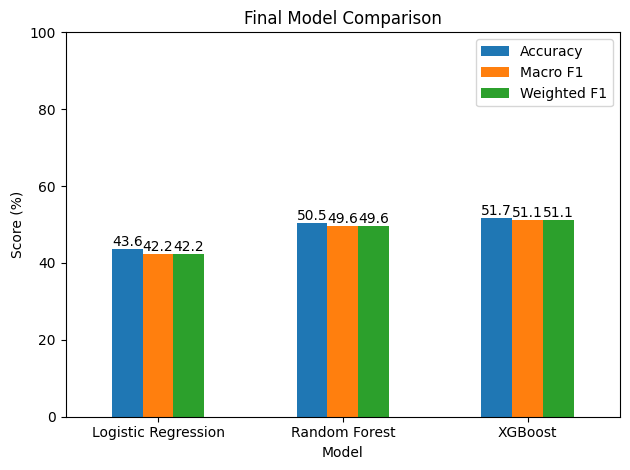

In [ ]:
import matplotlib.pyplot as plt

results_percent = results.copy()
results_percent[['Accuracy', 'Macro F1', 'Weighted F1']] *= 100

ax = results_percent.plot(
    x='Model',
    y=['Accuracy', 'Macro F1', 'Weighted F1'],
    kind='bar'
)

plt.title('Final Model Comparison')
plt.ylabel('Score (%)')
plt.xticks(rotation=0)
plt.ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

plt.tight_layout()
plt.show()

### 5.2 Random Forest Feature Importance

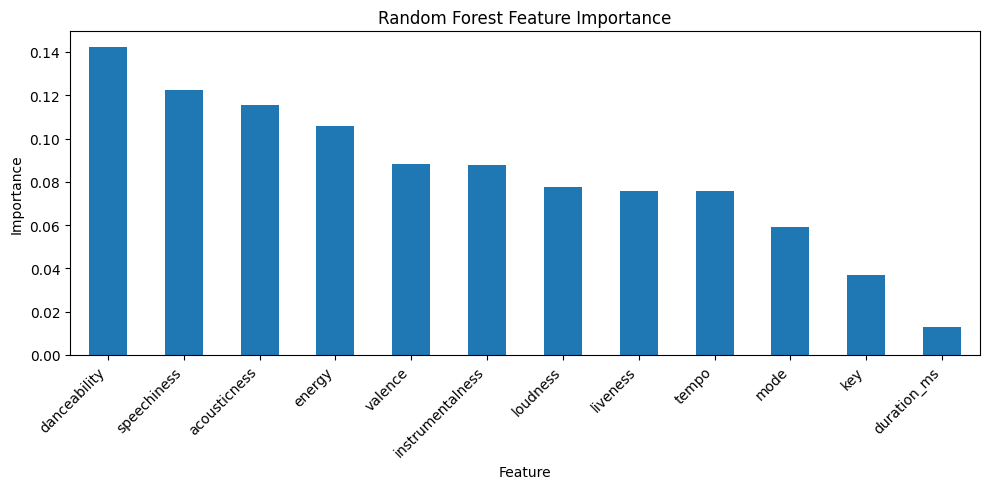

         Feature  Importance
    danceability    0.142400
     speechiness    0.122294
    acousticness    0.115633
          energy    0.105689
         valence    0.088217
instrumentalness    0.087602
        loudness    0.077401
        liveness    0.075662
           tempo    0.075641
            mode    0.059339
             key    0.036991
     duration_ms    0.013130


In [ ]:
feature_importance = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

feature_importance.plot(kind='bar', x='Feature', y='Importance', legend=False, figsize=(10, 5))
plt.title('Random Forest Feature Importance')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(feature_importance.to_string(index=False))

### 5.3 Confusion Matrix (Random Forest)

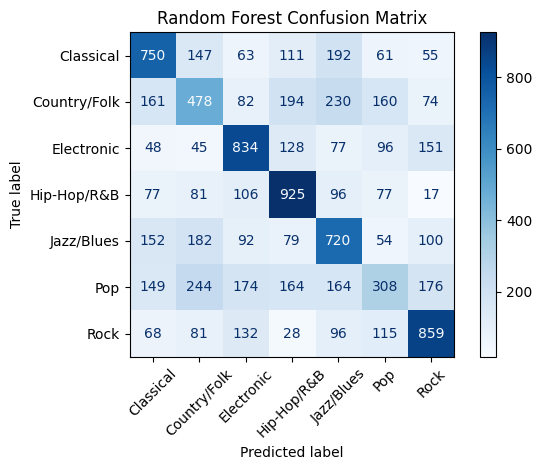

In [ ]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=rf_model.classes_,
    cmap='Blues',
    xticks_rotation=45
)
disp.ax_.set_title('Random Forest Confusion Matrix')
plt.tight_layout()
plt.show()

## 6. Summary

Among the three models tested for audio-only genre classification, XGBoost performed best, outperforming both Random Forest and Logistic Regression on the held-out test set. This suggests that genre boundaries in the audio-feature space are non-linear and are best captured by a boosted tree model rather than a linear baseline.

**Key findings:**
- Hip-Hop and Electronic were the most distinguishable genres (high F1) — their audio profiles are distinct.
- Folk and Pop had the lowest F1 — their audio patterns overlap heavily with other genres.
- Country had decent recall — the model found Country songs even if sometimes it misclassified others as Country.
- Top features: `speechiness`, `danceability`, `acousticness`, `energy`, `valence`.
- Least useful: `key`, `mode` — musical key is not genre-specific.


In [ ]:
import pickle

# Save model
with open('genre_xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_final, f)

# Save label encoder
with open('genre_label_encoder.pkl', 'wb') as f:
    pickle.dump(le_final, f)

# Save feature list
with open('genre_feature_list.pkl', 'wb') as f:
    pickle.dump(ALL_FEATURES, f)

In [ ]:
MODEL_PATH = '/content/drive/MyDrive/data-mining-spotify-team3/models'

import os
os.makedirs(MODEL_PATH, exist_ok=True)

with open(os.path.join(MODEL_PATH, 'genre_xgb_model.pkl'), 'wb') as f:
    pickle.dump(xgb_final, f)

with open(os.path.join(MODEL_PATH, 'genre_label_encoder.pkl'), 'wb') as f:
    pickle.dump(le_final, f)

with open(os.path.join(MODEL_PATH, 'genre_feature_list.pkl'), 'wb') as f:
    pickle.dump(ALL_FEATURES, f)